In [7]:
!pip install --upgrade tensorflow_datasets -q

In [2]:
!pip install emnist -q

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
!pip install --upgrade tensorflow_datasets -q

In [4]:
import torch
import torchvision
import numpy as np

train_dataset = torchvision.datasets.EMNIST(
    root='./data', split='letters', train=True, download=True
)
test_dataset = torchvision.datasets.EMNIST(
    root='./data', split='letters', train=False, download=True
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

100%|██████████| 562M/562M [00:04<00:00, 114MB/s]


Train samples: 124800
Test samples: 20800


In [5]:
X_train = train_dataset.data.numpy()
y_train = train_dataset.targets.numpy()
X_test = test_dataset.data.numpy()
y_test = test_dataset.targets.numpy()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Number of classes:", len(np.unique(y_train)))
print("Label range:", y_train.min(), "to", y_train.max())

Train shape: (124800, 28, 28)
Test shape: (20800, 28, 28)
Number of classes: 26
Label range: 1 to 26


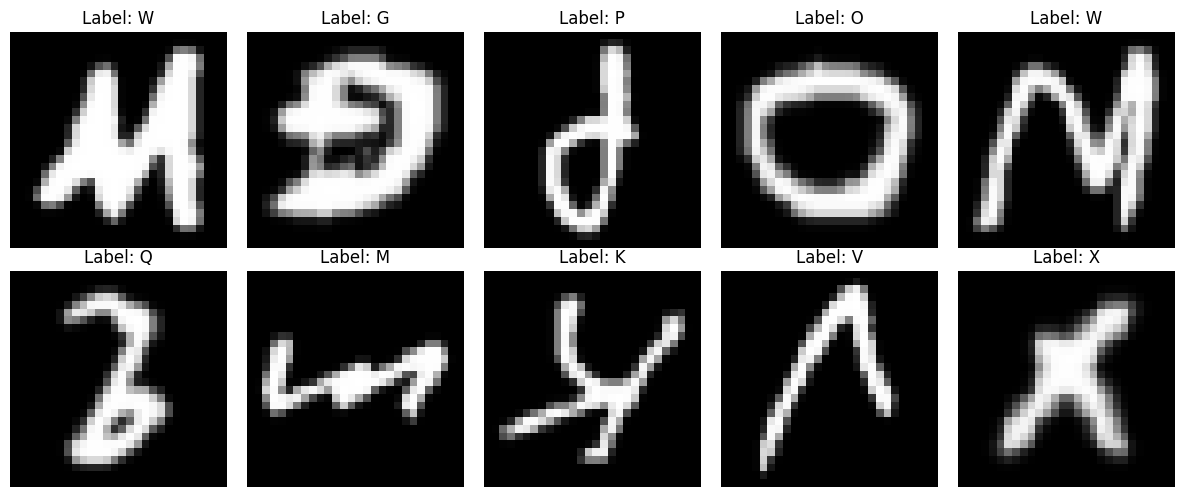

In [6]:
import matplotlib.pyplot as plt

def fix_orientation(img):
    return np.flipud(np.rot90(img, k=-1))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

letter_map = {i: chr(64 + i) for i in range(1, 27)}

for i in range(10):
    img = fix_orientation(X_train[i])
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Label: {letter_map[y_train[i]]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

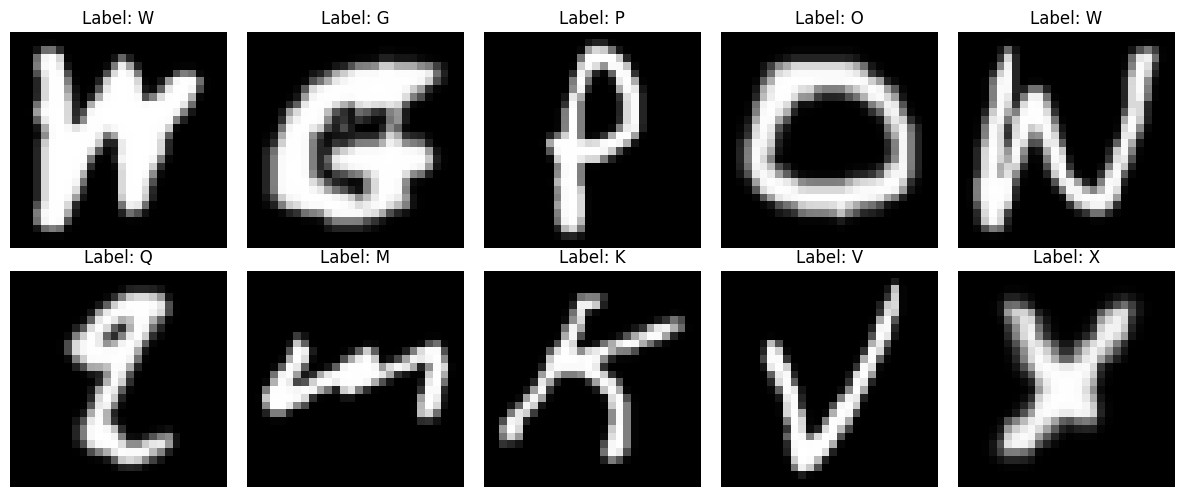

In [7]:
def fix_orientation(img):
    return np.rot90(np.fliplr(img), k=1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

letter_map = {i: chr(64 + i) for i in range(1, 27)}

for i in range(10):
    img = fix_orientation(X_train[i])
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Label: {letter_map[y_train[i]]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [8]:
X_train_fixed = np.array([fix_orientation(img) for img in X_train])
X_test_fixed = np.array([fix_orientation(img) for img in X_test])

print("Done fixing orientation for all images.")

Done fixing orientation for all images.


In [9]:
X_train_norm = X_train_fixed.astype('float32') / 255.0
X_test_norm = X_test_fixed.astype('float32') / 255.0

X_train_cnn = X_train_norm.reshape(-1, 28, 28, 1)
X_test_cnn = X_test_norm.reshape(-1, 28, 28, 1)

print("X_train shape:", X_train_cnn.shape)
print("X_test shape:", X_test_cnn.shape)

X_train shape: (124800, 28, 28, 1)
X_test shape: (20800, 28, 28, 1)


In [10]:
y_train_fixed = y_train - 1
y_test_fixed = y_test - 1

from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train_fixed, num_classes=26)
y_test_cat = to_categorical(y_test_fixed, num_classes=26)

print("y_train shape:", y_train_cat.shape)
print("Sample label (one-hot):", y_train_cat[0])
print("Corresponds to letter:", letter_map[y_train[0]])

y_train shape: (124800, 26)
Sample label (one-hot): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0.]
Corresponds to letter: W


In [11]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(26, activation='softmax')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,506 (955.10 KB)

 Trainable params: 244,058 (953.35 KB)

 Non-trainable params: 448 (1.75 KB)

In [13]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
history = model.fit(
    X_train_cnn, y_train_cat,
    validation_data=(X_test_cnn, y_test_cat),
    epochs=15,
    batch_size=128,
    verbose=1
)

Epoch 1/15
975/975 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8344 - loss: 0.5470 - val_accuracy: 0.9240 - val_loss: 0.2364
Epoch 2/15
975/975 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9117 - loss: 0.2771 - val_accuracy: 0.9302 - val_loss: 0.2121
Epoch 3/15
975/975 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9238 - loss: 0.2331 - val_accuracy: 0.9355 - val_loss: 0.1925
Epoch 4/15
975/975 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9309 - loss: 0.2089 - val_accuracy: 0.9382 - val_loss: 0.1939
Epoch 5/15
975/975 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9353 - loss: 0.1898 - val_accuracy: 0.9392 - val_loss: 0.1904
Epoch 6/15
975/975 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9389 - loss: 0.1772 - val_accuracy: 0.9398 - val_loss: 0.1911
Epoch 7/15
975/975 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9416 - loss: 0.1661 - val_accuracy: 0.9404 - val_loss: 0.1909
Epoch 8/15
975/975 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9444 - loss: 0.1555 - val_accuracy: 0

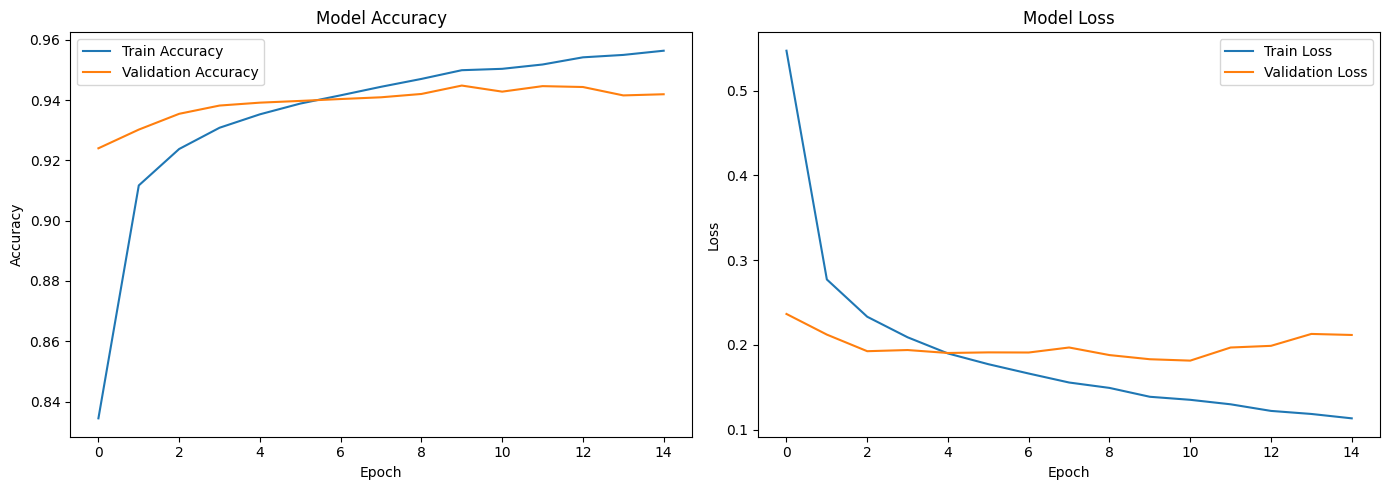

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_probs = model.predict(X_test_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_fixed

letter_names = [chr(65+i) for i in range(26)]
print(classification_report(y_true, y_pred, target_names=letter_names))

650/650 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
              precision    recall  f1-score   support

           A       0.92      0.96      0.94       800
           B       0.99      0.96      0.98       800
           C       0.95      0.99      0.97       800
           D       0.97      0.95      0.96       800
           E       0.98      0.96      0.97       800
           F       0.96      0.97      0.97       800
           G       0.91      0.81      0.86       800
           H       0.95      0.95      0.95       800
           I       0.73      0.80      0.76       800
           J       0.96      0.95      0.95       800
           K       0.99      0.96      0.97       800
           L       0.78      0.74      0.76       800
           M       0.98      0.99      0.99       800
           N       0.94      0.97      0.95       800
           O       0.97      0.96      0.97       800
           P       0.99      0.99      0.99       800
           Q       0.85      0.89      0

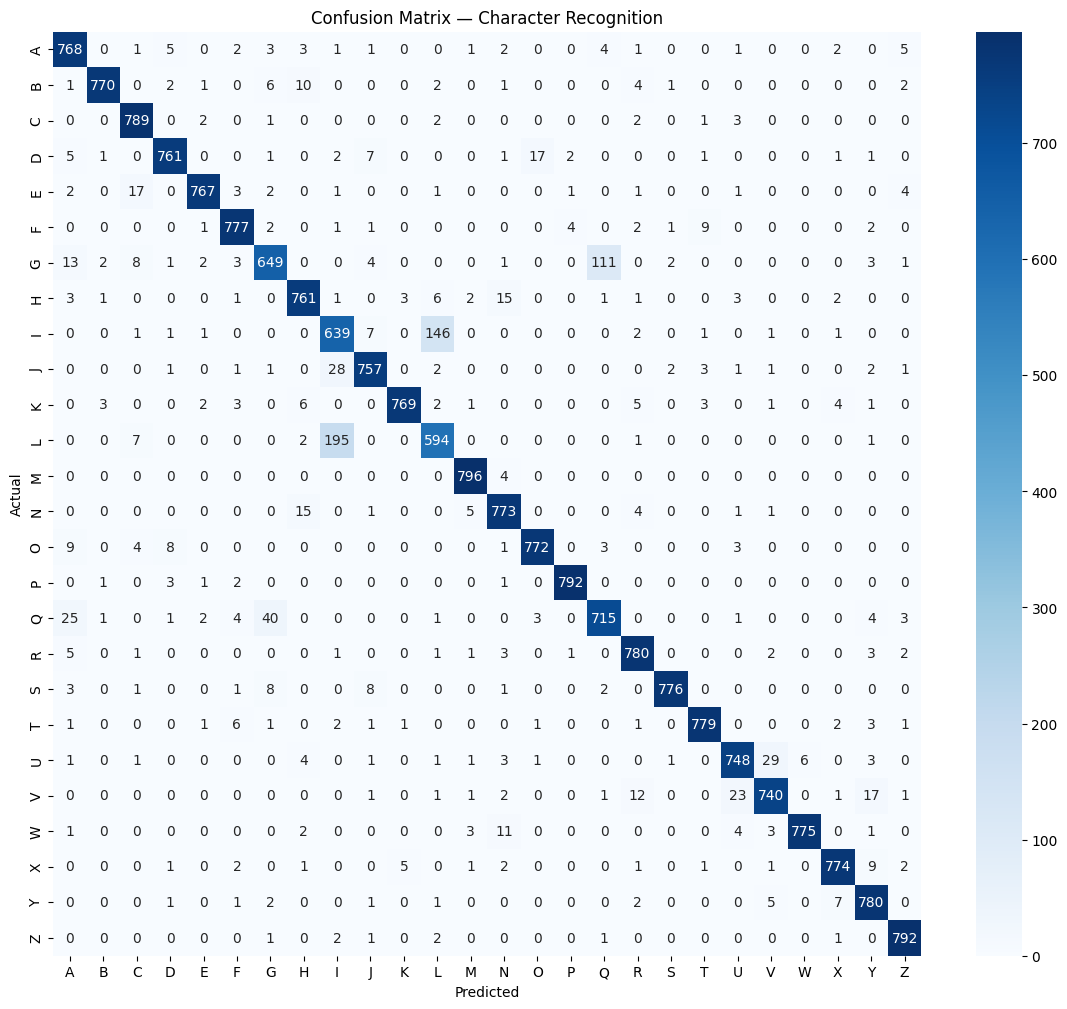

In [19]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=letter_names, yticklabels=letter_names)
plt.title('Confusion Matrix — Character Recognition')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [20]:
model.save('emnist_cnn_model.h5')
print("Model saved!")

Model saved!


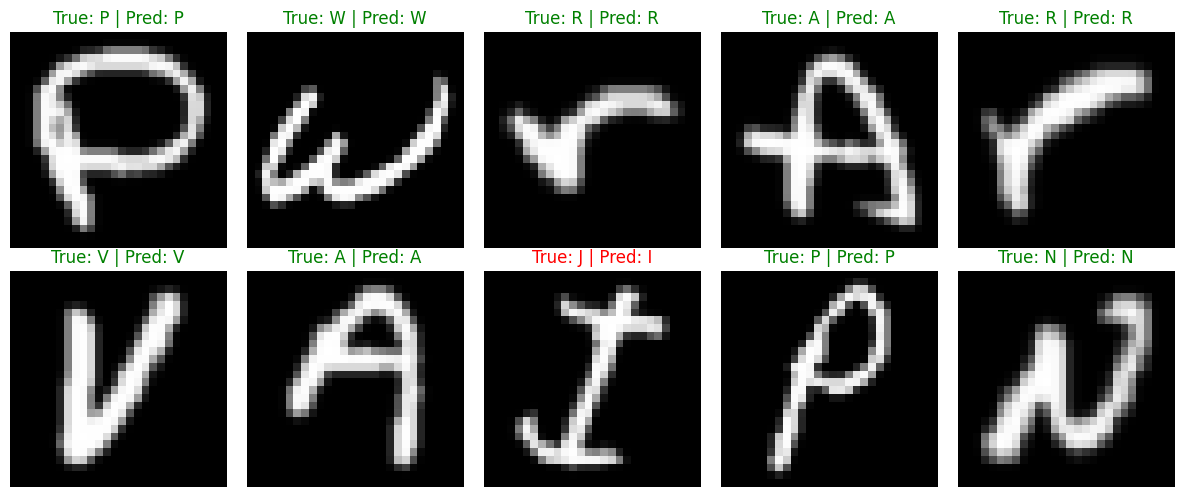

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

sample_indices = np.random.choice(len(X_test_cnn), 10, replace=False)

for i, idx in enumerate(sample_indices):
    img = X_test_cnn[idx].reshape(28, 28)
    true_label = letter_names[y_true[idx]]
    pred_label = letter_names[y_pred[idx]]
    color = 'green' if true_label == pred_label else 'red'

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"True: {true_label} | Pred: {pred_label}", color=color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()